# AM10 - Module: Elementary 

## Lecture 05


### Learning objectives:

Numerical differentiation

Taylor expansion, propagation of values

Introduce concept of "pseudocode": write out expressions that capture the math
as a set of instructions that can be easily translated to code

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Differentiation

Taking a derivative is one of the most important operations we can perform on a function. A derivative is defined as the difference of two values of the function $f(x)$, at two different values of the argument, $x=x_1$, $x=x_2$, $[f(x_2) - f(x_1)]$, in the limit when the latter difference $[x_2-x_1]$ tends to zero:

$$ \frac{df}{dx} = \lim_{|x_2-x_1|\to 0} \left [ \frac{f(x_2)-f(x_1)}{x_2-x_1} \right ]$$

This is easy to define and calculate numerically, as long as we can take values of $x$ that close enough to get a very good approximation of the derivative.
However, in actual applications we are stuck with a certain number of values of $x$ and 
the corresponding values of $f(x)$, so it important to take advantage of all the information 
we have intelligently to get the best possible numerical results.

#### Important points: 

1) "Forward" or "Backward"?  Makes no difference, should get the same result.  But it is useful to understand the difference in implementation and its consequences (see below).

"Forward": $$f' = \frac{f(n+1)-f(n)}{x(n+1)-x(n)}$$

"Backward": $$f' = \frac{f(n)-f(n+1)}{x(n)-x(n+1)}$$

Obviously the result is the same. But this needs to be applied consistently for the entire range of values, and it makes a difference if we assign the above value to be the derivative at $n$ or $n+1$.

2) For the FIRST DERIVATIVE:

a better approximation is to use the "middle point" of an interval

$${\rm Left}: \; f'(1) = \frac{f(1)-f(0)}{dx}, \; 
{\rm Right}: \; f'(1) = \frac{f(1)-f(2)}{-dx}$$

$${\rm Average}: \; f'(1) = \frac{1}{2}\left [\frac{f(1)-f(0)}{dx} + \frac{f(1)-f(2)}{-dx}\right] 
= \frac{f(2)-f(0)}{2(dx)}$$

$${\rm Generalize}: \; \; f'(n) = \frac{f(n+1)-f(n-1)}{2(dx)}$$

3) For the SECOND DERIVATIVE, the middle-point formula is:

$${\rm Left}: \; f''(1) = \frac{f'(1)-f'(0)}{dx} = \frac{1}{dx}\left [ 
\frac{f(2)-f(1)}{dx} - \frac{f(1)-f(0)}{dx} \right] = \frac{f(2)-2 f(1) + f(0)}{(dx)^2}$$ 

$${\rm Right}: \; f''(1) = \frac{f'(1)-f'(2)}{-dx} = \frac{1}{-dx}\left [ 
\frac{f(0)-f(1)}{-dx} - \frac{f(1)-f(2)}{-dx} \right] = \frac{f(0)-2 f(1) + f(2)}{(dx)^2}$$ 

but these two results are the same, so averaging gives the same result again!

$${\rm Generalize}: \; \; f''(n) = \frac{f(n+1)-2f(n)+f(n-1)}{(dx)^2}$$


3) We cannot apply the middle point rule for the first and last points: need to resort to nearest points only, about which we have information.

$${\rm Right}: \; f'(0) = \frac{f(0)-f(1)}{-dx} = \frac{f(1)-f(0)}{dx},$$ 

$${\rm Left}: \; f'(N) = \frac{f(N)-f(N-1)}{dx}$$ 

Better estimate is to assume linear extrapolation: linearity of the first derivative means

$$f'(n) = \frac{1}{2} \left [ f'(n+1) + f'(n-1) \right] \Rightarrow 
f'(n-1) = 2 f'(n) - f'(n+1), \; {\rm and} \;  f'(n+1) = 2 f'(n) - f'(n-1).$$

Applying these results to the end points, that is, for $n=1$ and for $n=N-1$, we get: 

$$f'(0) = 2 f'(1) - f'(2), \; \; {\rm and} \; \; f'(N) = 2 f'(N-1) - f'(N-2)$$

Similarly, for the second derivative at the end points we get:

$$f''(0) = 2 f''(1) - f''(2), \; \; {\rm and} \; \; f''(N) = 2 f''(N-1) - f''(N-2)$$

The linear extrapolation formulae give much better results because they contain 
information about the function from several more points than the two end points alone.


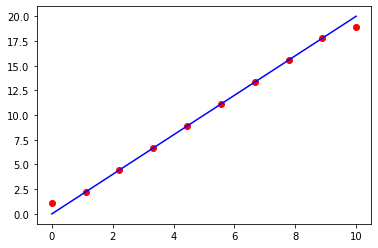

In [6]:
def fofx(n,nexp):
    y=x**nexp
    return y 
def d1fofx(x,nexp):
    y1=nexp*x**(nexp-1)
    return y1
Nx=10
xmin=0
xmax=10
x=np.linspace(xmin,xmax,Nx)
dx=x[1]-x[0]
nord=2
fx=fofx(x,nord)
d1f=d1fofx(x,nord)

for n in range(1,Nx-1):
    d1f[n]=(fx[n+1]-fx[n-1])/(2*dx)
    
##second derivative
## see lecture recording because some components were missed
d2f=np.zeros(Nx)
for n in range(1,Nx-1):
    d2f[n]=(fx[n+1]-2*fx[n]+fx[n-1])/dx**2
d2f[0]=2*d2f[1]-d2f[2]
d2f[Nx-1]=2*d2f[Nx-2]-d2f[Nx-3]
    
d1f[0]=(fx[1]-fx[0])/dx
d1f[Nx-1]=(fx[Nx-1]-fx[Nx-2])/dx
plt.plot(x,d1f,'ro')
plt.plot(x,d1fx,'b-')

In [ ]:
# Example 2: higher order derivative: second order



### 2. Taylor expansion

Explain the general expression of the Taylor expansion:  

$$ f(t) = f(t_0) + f'(t_0) (t-t_0) + \frac{1}{2!} f''(t_0) (t-t_0)^2 + \cdots + \frac{1}{n!} f^{(n)}(t_0) (t-t_0)^n + \cdots $$

where $f^{(n)}(t)$ is the $n^{\rm th}$ derivative; $f'(t_0)$ and $f''(t_0)$ are the first and second derivatives of the function $f(t)$ evaluated at the point $t=t_0$.

Here we will limit ourselves to expressions that involve up to 2nd derivative. 

#### Application: position as a function of time, using velocity and acceleration, for object falling with drag

The following is a simple application involving fall with drag, and taking advantage of the facts that velocity $v(t)$ and acceleration $a(t)$ are the first and second derivatives, resperctively, of the position $x(t)$:

$$v(t) = \frac{dx}{dt}, \; \; \; a(t) = \frac{dv}{dt} = \frac{d^2 x}{dt^2}$$

We will take the force $F$ acting on a falling body of mass $m$ along the vertical $x$-axis to be:

$$ F = -mg + \frac{1}{2} \gamma [v(t)]^2$$

where $g$ is the constant of gravity and $\gamma$ is the coefficient of drag [the last term is due to drag, which is proportional to the velocity $v(t)$ squared]. Since the force is given by Newton's Second Law as: $F=m a(t)$, where $a(t)$ is the instantaneous acceleration, we then have:

$$ a(t) = -g + \frac{\gamma}{2 m} [v(t)]^2$$

We can use the Taylor expansion to get the position $x(t)$ at every moment of time, given the intitial position $x(0)=x_0$ and velocity $v(0)=v_0$:

$$x(t+ dt) = x(t) + v(t) dt + \frac{1}{2} a(t) (dt)^2$$

by constantly updating the position, velocity and acceleration, starting at $t=0$, and using small increments of time $dt$. Using again the Taylor expansion, but keeping only up to first-order terms in $dt$, the velocity is given by:

$$v(t+dt) = v(t) + a(t) dt$$

###  Pseudocode

The above expressions lead to the following algorithm for the time propagation of position, velocity, acceleration:

\begin{eqnarray}
(0) & \; & {\rm Initialize}: \; t=0 \to a(0)=-g, \; v(0) = v_0, \; x(0) = x_0 \\
(1) & \; & \; \; \; a(t) = -g + \frac{\gamma}{2 m} [v(t)]^2 \\
(2) & \; & \; \; \; x(t+dt) = x(t) + v(t) dt + \frac{1}{2} a(t) (dt)^2 \\
(3) & \; & \; \; \; v(t+dt) = \frac{x(t+dt) -x(t)}{dt} \\
(4) & \; & \; \; \; {\rm SET} \; t \to (t+dt), \; \; \; {\rm GOTO} \;  (1) \\
\end{eqnarray}



### Important point to emphasize

The loop over the arrays above cannot go up to the last element of the array, because the loop involves $dt$ and $t+dt$, two successive points.  In the last step of the loop these will be $n$ and $n+1$, so $n$ cannot be the last array element, because $n+1$ would exceed the array dimension!


In [ ]:
# Example 3: falling object with drag



#### EXERCISE: 
write the above algorithm using a "while" loop, allowing propagation for as long as the acceleration is non-zero to within a tolerance